# ODMR: load saved arrays → plot → fit

This notebook is analysis-only:

- Load the saved `data.json` + `arrays.npz` (DataHandler format)
- Plot the raw arrays and normalized ODMR
- Fit the resonance (works for CW and pulsed datasets)

## 1) Imports + locate NV2_array

In [1]:
from __future__ import annotations
import sys
from pathlib import Path
import matplotlib.pyplot as plt
import numpy as np
from nv2_analysis.dataset import DatasetReader  # noqa: E402
from nv2_analysis.fits import ExperimentFitter  # noqa: E402
from importlib import reload
import nv2_analysis.fits as fits

def find_workspace_root(start: Path) -> Path:
    start = start.resolve()
    for p in [start, *start.parents]:
        if (p / 'qua-libs').exists():
            return p
    raise RuntimeError('Could not find workspace root containing qua-libs')

WORKSPACE = find_workspace_root(Path.cwd())
ANALYSIS = (WORKSPACE / 'qua-libs/Quantum-Control-Applications/Optically addressable spin qubits/NV2_array/analysis').resolve()
NV2 = ANALYSIS.parent
DATA_ROOT = NV2 / 'Data'
sys.path.insert(0, str(ANALYSIS))
plt.rcParams['figure.figsize'] = (9, 5)

CC_NS = 4.0 # 4 ns per clock cycle

2026-03-03 13:25:58,875 - qm - INFO     - Starting session: 3a928a1d-7712-454f-8808-71256d6bec59


## 2) Load saved arrays

In [2]:
# Toggle whether to use LO frequency (absolute MW freq) or just IF
USE_LO_FREQUENCY = False  # Set False to work in IF space

reader = DatasetReader(nv_root=NV2, data_root=DATA_ROOT)
EXPERIMENT_TAG = 'odmr'  # matches folder names like '#1_cw_odmr_...' or '#24_pulsed_odmr_...'
# Choose a specific dataset folder or leave None for latest matching tag:
# DATASET = r'2025-12-31\\#1_cw_odmr_122033'
# DATASET = r'C:\\\\...\\\\NV2_array\\\\Data\\\\2025-12-31\\\\#1_cw_odmr_122033'
DATASET = None
#DATASET = r'2026-03-02\#480_pulsed_odmr_204759'

def find_latest_by_tag(tag: str) -> Path:
    candidates = [p.parent for p in DATA_ROOT.rglob('data.json') if p.is_file() and tag in p.parent.name.lower()]
    if not candidates:
        raise FileNotFoundError(f"No datasets matching tag {tag!r} under {DATA_ROOT}")
    candidates.sort(key=lambda p: p.stat().st_mtime, reverse=True)
    return candidates[0]

ds_folder = find_latest_by_tag(EXPERIMENT_TAG) if DATASET is None else reader.resolve_dataset(DATASET).folder
ds = reader.resolve_dataset(ds_folder)
data = reader.load(ds)

if_hz = np.asarray(data['IF_frequencies'], dtype=float)
counts_data = np.asarray(data['counts_data'], dtype=float)
counts_ref_data = np.asarray(data['counts_ref_data'], dtype=float)

cfg = data.get('config') or {}
if USE_LO_FREQUENCY:
    lo_hz = float(cfg['elements']['NV']['mixInputs']['lo_frequency'])
    f_mw_hz = lo_hz + if_hz
else:
    lo_hz = None
    f_mw_hz = if_hz

pulses = cfg.get('pulses') or {}
readout_len_ns = float(pulses['readout_pulse_1']['length'])
meas_len_s = readout_len_ns * 1e-9

signal_kcps = counts_data / 1000.0 / meas_len_s
ref_kcps = counts_ref_data / 1000.0 / meas_len_s

with np.errstate(divide='ignore', invalid='ignore'):
    contrast = 1- (ref_kcps - signal_kcps) / ref_kcps

print(f'Loaded: {ds.folder.relative_to(DATA_ROOT)}')

Loaded: 2026-03-03\#492_pulsed_odmr_132502


## 3) Plot original arrays

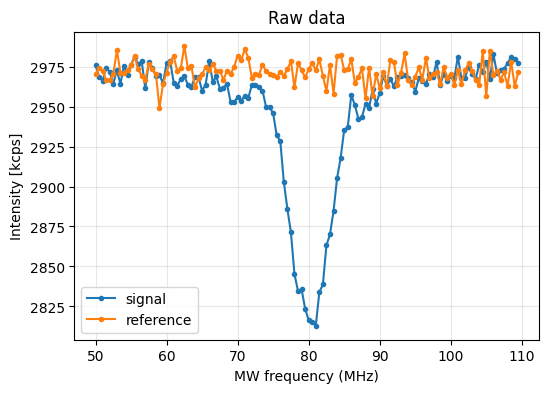

In [3]:
# fig, ax = plt.subplots(2, 1, figsize=(6, 8))

# ax[0].plot(f_mw_hz / 1e6, signal_kcps, 'o-', ms=3, label='signal')
# ax[0].plot(f_mw_hz / 1e6, ref_kcps, 'o-', ms=3, label='reference')
# ax[0].set_xlabel('MW frequency (MHz)')
# ax[0].set_ylabel('Intensity [kcps]')
# ax[0].set_title('Raw data')
# ax[0].grid(True, alpha=0.3)
# ax[0].legend()

# ax[1].plot(f_mw_hz / 1e6, contrast, 'o-', ms=3)
# ax[1].set_xlabel('MW frequency (MHz)')
# ax[1].set_ylabel('Contrast [a.u.]')
# ax[1].set_title('Normalized signal')
# ax[1].grid(True, alpha=0.3)

plt.figure(figsize=(6, 4))
plt.plot(f_mw_hz / 1e6, signal_kcps, 'o-', ms=3, label='signal')
plt.plot(f_mw_hz / 1e6, ref_kcps, 'o-', ms=3, label='reference')
plt.xlabel('MW frequency (MHz)')
plt.ylabel('Intensity [kcps]')
plt.title('Raw data')
plt.grid(True, alpha=0.3)
plt.legend()
plt.show()

## 4) Fit

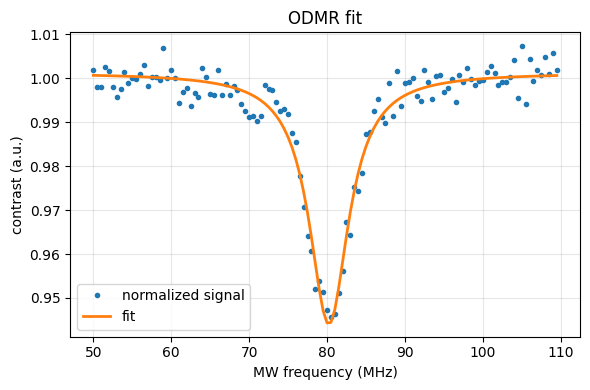

Fit results:
- f0: 80.234438 MHz
- FWHM: 6.137514 MHz
- amplitude: 0.0572891


In [4]:
reload(fits)
fitter = fits.ExperimentFitter()
fit_res = fitter.fit_cw_odmr(f_mw_hz, -(contrast-1), lo_hz=lo_hz)

x_hz = getattr(fit_res, 'x', None)
y_contrast = getattr(fit_res, 'y', None)
y_fit = getattr(fit_res, 'y_fit', None)
if x_hz is None:
    x_hz = f_mw_hz
if y_contrast is None:
    y_contrast = contrast
x_mhz = np.asarray(x_hz, dtype=float) / 1e6
y_dip = 1.0 - np.asarray(y_contrast, dtype=float)

plt.figure(figsize=(6, 4))
plt.plot(x_mhz, y_dip, 'o', ms=3, label='normalized signal')
if y_fit is not None:
    plt.plot(x_mhz, 1.0 - np.asarray(y_fit, dtype=float), '-', lw=2, label='fit')
plt.xlabel('MW frequency (MHz)')
plt.ylabel('contrast (a.u.)')
plt.title('ODMR fit')
plt.grid(True, alpha=0.3)
plt.legend()
plt.tight_layout()
plt.show()

# Then print fit details
print('Fit results:')
print(f"- f0: {fit_res.params['f0_hz']/1e6:.6f} MHz")
if fit_res.params.get('suggested_NV_IF_freq_hz') is not None:
    print(f"- suggested NV IF: {fit_res.params['suggested_NV_IF_freq_hz']/1e6:.6f} MHz")
print(f"- FWHM: {fit_res.params['fwhm_hz']/1e6:.6f} MHz")
print(f"- amplitude: {fit_res.params['amplitude']:.6g}")

In [6]:
#estimate SNR 
#calculate noise floor from off-resonance points
sigma = np.std(y_contrast[(x_hz < fit_res.params['f0_hz'] - 20e6) | (x_hz > fit_res.params['f0_hz'] + 20e6)])
#sigma = np.std(y_contrast[(x_hz < fit_res.params['f0_hz'] - 15e6) | (x_hz > fit_res.params['f0_hz'] +15e6)])

SNR = fit_res.params['amplitude'] / sigma
print(f"- noise floor (sigma): {sigma:.6g}")
print(f"- SNR: {SNR:.2f}")

- noise floor (sigma): 0.00284888
- SNR: 20.11
